# Make Figures for second section of Results

"3.3 Linking changes in mixing and SAMW volume"

 - Figure 3 (pacemaker experiments)

## imports

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import xarray as xr
import dask as da
from dask.diagnostics import ProgressBar
import gsw as gsw

# plotting packages
#import seaborn as sb
#sb.set(style='ticks')
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from matplotlib import colors
import cmocean.cm as cmo
from cmocean.tools import lighten
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.util as cutil

import xesmf as xe 

wrkdir = "/expanse/lustre/projects/ciw112/pbuchanan/JRA55"
os.chdir(wrkdir)

# activate the dask progress bar
ProgressBar().register()

# ignore warnings
import warnings
warnings.filterwarnings("ignore")

os.getcwd()


'/expanse/lustre/projects/ciw112/pbuchanan/JRA55'

## load in the model data

In [2]:
%%time

# model output

temp = xr.open_dataset('JRA55_pic_1m_ts_1958-2022.nc')['thetao']
salt = xr.open_dataset('JRA55_pic_1m_ts_1958-2022.nc')['so']

mldSEp = xr.open_dataset('JRA55_SEPac_5d_grid_T_Y2022.nc')['mldr10_1']
mldSWp = xr.open_dataset('JRA55_SWPac_5d_grid_T_Y2022.nc')['mldr10_1']
tempSEp = xr.open_dataset('JRA55_SEPac_1m_grid_T_Y2022.nc')['thetao']
saltSEp = xr.open_dataset('JRA55_SEPac_1m_grid_T_Y2022.nc')['so']
tempSWp = xr.open_dataset('JRA55_SWPac_1m_grid_T_Y2022.nc')['thetao']
saltSWp = xr.open_dataset('JRA55_SWPac_1m_grid_T_Y2022.nc')['so']

mldSEi = xr.open_dataset('JRA55_SEInd_5d_grid_T_Y2022.nc')['mldr10_1']
mldSWi = xr.open_dataset('JRA55_SWInd_5d_grid_T_Y2022.nc')['mldr10_1']
tempSEi = xr.open_dataset('JRA55_SEInd_1m_grid_T_Y2022.nc')['thetao']
saltSEi = xr.open_dataset('JRA55_SEInd_1m_grid_T_Y2022.nc')['so']
tempSWi = xr.open_dataset('JRA55_SWInd_1m_grid_T_Y2022.nc')['thetao']
saltSWi = xr.open_dataset('JRA55_SWInd_1m_grid_T_Y2022.nc')['so']

tempI = xr.open_dataset('JRA55_Ind_1m_grid_T_Y2022.nc')['thetao']
saltI = xr.open_dataset('JRA55_Ind_1m_grid_T_Y2022.nc')['so']
tempP = xr.open_dataset('JRA55_Pac_1m_grid_T_Y2022.nc')['thetao']
saltP = xr.open_dataset('JRA55_Pac_1m_grid_T_Y2022.nc')['so']


deps = tempSEp['deptht']

# grab the volume of grid cells on the tracer grid
data = xr.open_dataset('ORCA2.0.full_grid.nc')
lons = data['lon']
lats = data['lat']
lons_bnds = data['bounds_lon']
lats_bnds = data['bounds_lat']

data = xr.open_dataset('ORCA2_xyz_grid_T.nc')
dxt = data['e1t']
dyt = data['e2t']
dzt = data['e3t']
volume = dxt * dyt * dzt
area = dxt * dyt

data.close()



CPU times: user 207 ms, sys: 80.2 ms, total: 287 ms
Wall time: 59.6 s


## rename some dimensions/coordinates

In [3]:
%%time

month = np.arange(1,13,1)
year = np.arange(1958.5,2022.51,1)

temp = temp.assign_coords(record=year, time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'record':'year', 'time_counter':'month', 'deptht':'depth'})
salt = salt.assign_coords(record=year, time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'record':'year', 'time_counter':'month', 'deptht':'depth'})

mldSEp = mldSEp.rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'time'})
mldSWp = mldSWp.rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'time'})
mldSEi = mldSEi.rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'time'})
mldSWi = mldSWi.rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'time'})

tempP = tempP.assign_coords(time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'month', 'deptht':'depth'})
saltP = saltP.assign_coords(time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'month', 'deptht':'depth'})
tempI = tempI.assign_coords(time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'month', 'deptht':'depth'})
saltI = saltI.assign_coords(time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'month', 'deptht':'depth'})
tempSEp = tempSEp.assign_coords(time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'month', 'deptht':'depth'})
saltSEp = saltSEp.assign_coords(time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'month', 'deptht':'depth'})
tempSWp = tempSWp.assign_coords(time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'month', 'deptht':'depth'})
saltSWp = saltSWp.assign_coords(time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'month', 'deptht':'depth'})
tempSEi = tempSEi.assign_coords(time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'month', 'deptht':'depth'})
saltSEi = saltSEi.assign_coords(time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'month', 'deptht':'depth'})
tempSWi = tempSWi.assign_coords(time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'month', 'deptht':'depth'})
saltSWi = saltSWi.assign_coords(time_counter=month).rename({'nav_lon':'lon', 'nav_lat':'lat', 'time_counter':'month', 'deptht':'depth'})

volume = volume.rename({"deptht":"depth"})



CPU times: user 14.6 ms, sys: 0 ns, total: 14.6 ms
Wall time: 14.6 ms


## chunk the datasets

In [4]:
%%time

chunky = {'year':1, 'month':1, 'depth':31, 'y':149, 'x':182}
temp = temp.chunk(chunks=chunky).drop_vars('time_centered')
salt = salt.chunk(chunks=chunky).drop_vars('time_centered')

chunky = {'month':1, 'depth':31, 'y':149, 'x':182}
mldSEp = mldSEp.drop_vars('time_centered')
mldSWp = mldSWp.drop_vars('time_centered')
tempSEp = tempSEp.chunk(chunks=chunky).drop_vars('time_centered')
saltSEp = saltSEp.chunk(chunks=chunky).drop_vars('time_centered')
tempSWp = tempSWp.chunk(chunks=chunky).drop_vars('time_centered')
saltSWp = saltSWp.chunk(chunks=chunky).drop_vars('time_centered')

mldSEi = mldSEi.drop_vars('time_centered')
mldSWi = mldSWi.drop_vars('time_centered')
tempSEi = tempSEi.chunk(chunks=chunky).drop_vars('time_centered')
saltSEi = saltSEi.chunk(chunks=chunky).drop_vars('time_centered')
tempSWi = tempSWi.chunk(chunks=chunky).drop_vars('time_centered')
saltSWi = saltSWi.chunk(chunks=chunky).drop_vars('time_centered')

tempP = tempP.chunk(chunks=chunky).drop_vars('time_centered')
saltP = saltP.chunk(chunks=chunky).drop_vars('time_centered')
tempI = tempI.chunk(chunks=chunky).drop_vars('time_centered')
saltI = saltI.chunk(chunks=chunky).drop_vars('time_centered')


CPU times: user 23.8 ms, sys: 1.85 ms, total: 25.7 ms
Wall time: 26.1 ms


## make new depth to regrid to and also the new volumes of the cells

100 100
CPU times: user 18.5 ms, sys: 4.01 ms, total: 22.5 ms
Wall time: 22.2 ms


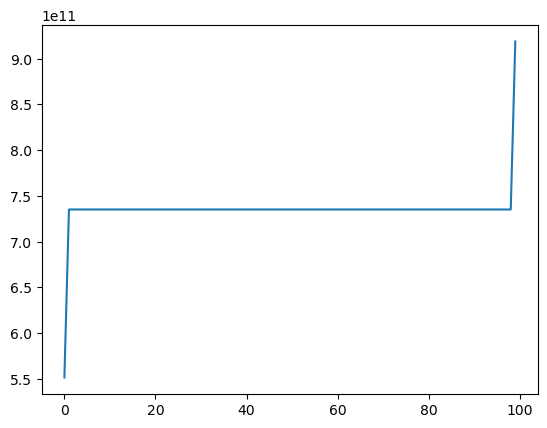

In [5]:
%%time

new_depth = np.arange(5,2001,20)
new_depth_thick = np.arange(-5,2001,20)
new_depth_thick[0] = 0; new_depth_thick[-1] = 2000; 
new_depth_thick = np.diff(new_depth_thick)
print(len(new_depth), len(new_depth_thick))

new_depth_thick = new_depth_thick[:, np.newaxis, np.newaxis]
new_depth_thick = np.broadcast_to(new_depth_thick, (100,149,182))

dep_thick = xr.DataArray(
    new_depth_thick,
    dims=["depth", "y", "x"],
    coords={"depth": new_depth, "x":area.x, "y":area.y}
    )

vol = area.expand_dims({"depth": dep_thick.depth})
vol = vol * dep_thick

plt.figure()
plt.plot(vol.isel(x=40, y=49))


## regrid the depth coordinate to finer resolution in the upper 2000 metres

[########################################] | 100% Completed | 101.01 ms
[########################################] | 100% Completed | 100.89 ms
[########################################] | 100% Completed | 100.63 ms
[########################################] | 100% Completed | 100.66 ms
[########################################] | 100% Completed | 100.97 ms
[########################################] | 100% Completed | 100.69 ms
[########################################] | 100% Completed | 100.60 ms
[########################################] | 100% Completed | 100.65 ms
[########################################] | 100% Completed | 100.79 ms
[########################################] | 100% Completed | 100.68 ms
[########################################] | 100% Completed | 100.92 ms
[########################################] | 100% Completed | 100.86 ms
[########################################] | 100% Completed | 100.64 ms
[########################################] | 100% Completed | 10

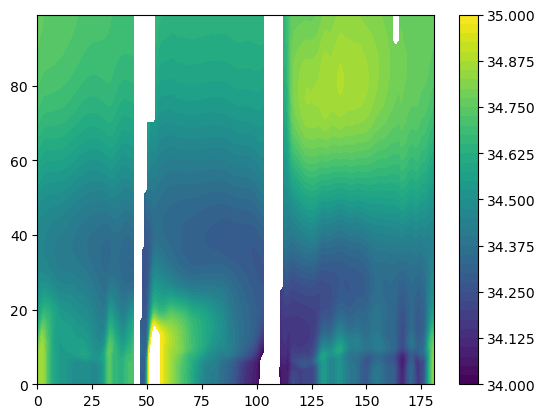

In [6]:
%%time

temp_lin = temp.where(salt>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')
salt_lin = salt.where(salt>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')
temp = temp.where(salt>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')
salt = salt.where(salt>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')
temp = temp.where(~np.isnan(salt),other=0.0).isel(depth=slice(0,25))
salt = salt.where(~np.isnan(salt),other=0.0).isel(depth=slice(0,25))
temp_cub = temp.interp(depth=new_depth, method='cubic').where(salt_lin>0.0, other=np.nan)
salt_cub = salt.interp(depth=new_depth, method='cubic').where(salt_lin>0.0, other=np.nan)

tempP_lin = tempP.where(saltP>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')
saltP_lin = saltP.where(saltP>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')
tempP = tempP.where(saltP>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')
saltP = saltP.where(saltP>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')
tempP = tempP.where(~np.isnan(saltP),other=0.0).isel(depth=slice(0,25))
saltP = saltP.where(~np.isnan(saltP),other=0.0).isel(depth=slice(0,25))
tempP_cub = tempP.interp(depth=new_depth, method='cubic').where(saltP_lin>0.0, other=np.nan)
saltP_cub = saltP.interp(depth=new_depth, method='cubic').where(saltP_lin>0.0, other=np.nan)

tempI_lin = tempI.where(saltI>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')
saltI_lin = saltI.where(saltI>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')
tempI = tempI.where(saltI>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')
saltI = saltI.where(saltI>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')
tempI = tempI.where(~np.isnan(saltI),other=0.0).isel(depth=slice(0,25))
saltI = saltI.where(~np.isnan(saltI),other=0.0).isel(depth=slice(0,25))
tempI_cub = tempI.interp(depth=new_depth, method='cubic').where(saltI_lin>0.0, other=np.nan)
saltI_cub = saltI.interp(depth=new_depth, method='cubic').where(saltI_lin>0.0, other=np.nan)

tempSEp_lin = tempSEp.where(saltSEp>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')
saltSEp_lin = saltSEp.where(saltSEp>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')
tempSWp_lin = tempSWp.where(saltSWp>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')
saltSWp_lin = saltSWp.where(saltSWp>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')

tempSEp = tempSEp.where(saltSEp>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')
saltSEp = saltSEp.where(saltSEp>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')
tempSWp = tempSWp.where(saltSWp>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')
saltSWp = saltSWp.where(saltSWp>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')

tempSEp = tempSEp.where(~np.isnan(saltSEp),other=0.0).isel(depth=slice(0,25))
saltSEp = saltSEp.where(~np.isnan(saltSEp),other=0.0).isel(depth=slice(0,25))
tempSWp = tempSWp.where(~np.isnan(saltSWp),other=0.0).isel(depth=slice(0,25))
saltSWp = saltSWp.where(~np.isnan(saltSWp),other=0.0).isel(depth=slice(0,25))

tempSEp_cub = tempSEp.interp(depth=new_depth, method='cubic').where(saltSEp_lin>0.0, other=np.nan)
saltSEp_cub = saltSEp.interp(depth=new_depth, method='cubic').where(saltSEp_lin>0.0, other=np.nan)
tempSWp_cub = tempSWp.interp(depth=new_depth, method='cubic').where(saltSWp_lin>0.0, other=np.nan)
saltSWp_cub = saltSWp.interp(depth=new_depth, method='cubic').where(saltSWp_lin>0.0, other=np.nan)

plt.figure()
p1 = plt.contourf(saltSEp_cub.isel(month=7,y=40), levels=np.arange(34.0,35.01,0.025))
plt.colorbar(p1)


[########################################] | 100% Completed | 100.96 ms
[########################################] | 100% Completed | 100.73 ms
[########################################] | 100% Completed | 100.63 ms
[########################################] | 100% Completed | 100.73 ms
[########################################] | 100% Completed | 101.17 ms
[########################################] | 100% Completed | 100.73 ms
[########################################] | 100% Completed | 100.61 ms
[########################################] | 100% Completed | 100.98 ms
[########################################] | 100% Completed | 101.05 ms
[########################################] | 100% Completed | 100.66 ms
[########################################] | 100% Completed | 100.77 ms
[########################################] | 100% Completed | 100.68 ms
[########################################] | 100% Completed | 100.67 ms
[########################################] | 100% Completed | 10

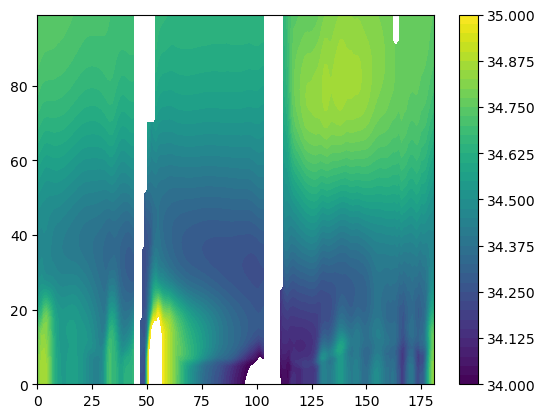

In [7]:
%%time

tempSEi_lin = tempSEi.where(saltSEi>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')
saltSEi_lin = saltSEi.where(saltSEi>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')
tempSWi_lin = tempSWi.where(saltSWi>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')
saltSWi_lin = saltSWi.where(saltSWi>0.0, other=np.nan).isel(depth=slice(0,25)).interp(depth=new_depth, method='linear')

tempSEi = tempSEi.where(saltSEi>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')
saltSEi = saltSEi.where(saltSEi>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')
tempSWi = tempSWi.where(saltSWi>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')
saltSWi = saltSWi.where(saltSWi>0.0, other=np.nan).interpolate_na(dim='x', method='linear').interpolate_na(dim='y', method='linear').interpolate_na(dim='depth', method='linear')

tempSEi = tempSEi.where(~np.isnan(saltSEi),other=0.0).isel(depth=slice(0,25))
saltSEi = saltSEi.where(~np.isnan(saltSEi),other=0.0).isel(depth=slice(0,25))
tempSWi = tempSWi.where(~np.isnan(saltSWi),other=0.0).isel(depth=slice(0,25))
saltSWi = saltSWi.where(~np.isnan(saltSWi),other=0.0).isel(depth=slice(0,25))

tempSEi_cub = tempSEi.interp(depth=new_depth, method='cubic').where(saltSEi_lin>0.0, other=np.nan)
saltSEi_cub = saltSEi.interp(depth=new_depth, method='cubic').where(saltSEi_lin>0.0, other=np.nan)
tempSWi_cub = tempSWi.interp(depth=new_depth, method='cubic').where(saltSWi_lin>0.0, other=np.nan)
saltSWi_cub = saltSWi.interp(depth=new_depth, method='cubic').where(saltSWi_lin>0.0, other=np.nan)

plt.figure()
p1 = plt.contourf(saltSEi_cub.isel(month=7,y=40), levels=np.arange(34.0,35.01,0.025))
plt.colorbar(p1)


## calculate the density

In [8]:
%%time

rho0_lin = gsw.density.sigma0(salt_lin, temp_lin)
rho0_cub = gsw.density.sigma0(salt_cub, temp_cub)
rho0P_lin = gsw.density.sigma0(saltP_lin, tempP_lin)
rho0I_lin = gsw.density.sigma0(saltI_lin, tempI_lin)
rho0P_cub = gsw.density.sigma0(saltP_cub, tempP_cub)
rho0I_cub = gsw.density.sigma0(saltI_cub, tempI_cub)
rho0SEp_lin = gsw.density.sigma0(saltSEp_lin, tempSEp_lin)
rho0SWp_lin = gsw.density.sigma0(saltSWp_lin, tempSWp_lin)
rho0SEi_lin = gsw.density.sigma0(saltSEi_lin, tempSEi_lin)
rho0SWi_lin = gsw.density.sigma0(saltSWi_lin, tempSWi_lin)
rho0SEp_cub = gsw.density.sigma0(saltSEp_cub, tempSEp_cub)
rho0SWp_cub = gsw.density.sigma0(saltSWp_cub, tempSWp_cub)
rho0SEi_cub = gsw.density.sigma0(saltSEi_cub, tempSEi_cub)
rho0SWi_cub = gsw.density.sigma0(saltSWi_cub, tempSWi_cub)

# mask rho0 where there are zeros
rho0_lin = rho0_lin.where(rho0_lin > 0.0, other=np.nan)
rho0_cub = rho0_cub.where(rho0_cub > 0.0, other=np.nan)
rho0P_lin = rho0P_lin.where(rho0P_lin > 0.0, other=np.nan)
rho0I_lin = rho0I_lin.where(rho0I_lin > 0.0, other=np.nan)
rho0P_cub = rho0P_cub.where(rho0P_cub > 0.0, other=np.nan)
rho0I_cub = rho0I_cub.where(rho0I_cub > 0.0, other=np.nan)
rho0SEp_lin = rho0SEp_lin.where(rho0SEp_lin > 0.0, other=np.nan)
rho0SWp_lin = rho0SWp_lin.where(rho0SWp_lin > 0.0, other=np.nan)
rho0SEi_lin = rho0SEi_lin.where(rho0SEi_lin > 0.0, other=np.nan)
rho0SWi_lin = rho0SWi_lin.where(rho0SWi_lin > 0.0, other=np.nan)
rho0SEp_cub = rho0SEp_cub.where(rho0SEp_cub > 0.0, other=np.nan)
rho0SWp_cub = rho0SWp_cub.where(rho0SWp_cub > 0.0, other=np.nan)
rho0SEi_cub = rho0SEi_cub.where(rho0SEi_cub > 0.0, other=np.nan)
rho0SWi_cub = rho0SWi_cub.where(rho0SWi_cub > 0.0, other=np.nan)


[########################################] | 100% Completed | 101.12 ms
[########################################] | 100% Completed | 100.63 ms
[########################################] | 100% Completed | 100.71 ms
[########################################] | 100% Completed | 100.60 ms
[########################################] | 100% Completed | 100.63 ms
[########################################] | 100% Completed | 100.62 ms
[########################################] | 100% Completed | 100.66 ms
[########################################] | 100% Completed | 100.60 ms
[########################################] | 100% Completed | 100.78 ms
[########################################] | 100% Completed | 100.78 ms
[########################################] | 100% Completed | 100.60 ms
[########################################] | 100% Completed | 100.79 ms
[########################################] | 100% Completed | 100.58 ms
[########################################] | 100% Completed | 10

## vertical gradient in potential density

In [9]:
%%time

dpdz_lin = rho0_lin.differentiate('depth')
dpdz_cub = rho0_cub.differentiate('depth')

dpdzP_lin = rho0P_lin.differentiate('depth')
dpdzP_cub = rho0P_cub.differentiate('depth')

dpdzI_lin = rho0I_lin.differentiate('depth')
dpdzI_cub = rho0I_cub.differentiate('depth')

dpdzSEp_lin = rho0SEp_lin.differentiate('depth')
dpdzSWp_lin = rho0SWp_lin.differentiate('depth')
dpdzSEp_cub = rho0SEp_cub.differentiate('depth')
dpdzSWp_cub = rho0SWp_cub.differentiate('depth')

dpdzSEi_lin = rho0SEi_lin.differentiate('depth')
dpdzSWi_lin = rho0SWi_lin.differentiate('depth')
dpdzSEi_cub = rho0SEi_cub.differentiate('depth')
dpdzSWi_cub = rho0SWi_cub.differentiate('depth')


CPU times: user 41.1 ms, sys: 1.97 ms, total: 43 ms
Wall time: 42.9 ms


## calculate the "thermostad", the change in depth per degree C


In [10]:
%%time 

dtdz_lin = temp_lin.differentiate('depth')
dzdt_lin = np.abs(1.0/dtdz_lin)
dtdz_cub = temp_cub.differentiate('depth')
dzdt_cub = np.abs(1.0/dtdz_cub)

dtdzP_lin = tempP_lin.differentiate('depth')
dzdtP_lin = np.abs(1.0/dtdzP_lin)
dtdzP_cub = tempP_cub.differentiate('depth')
dzdtP_cub = np.abs(1.0/dtdzP_cub)

dtdzI_lin = tempI_lin.differentiate('depth')
dzdtI_lin = np.abs(1.0/dtdzI_lin)
dtdzI_cub = tempI_cub.differentiate('depth')
dzdtI_cub = np.abs(1.0/dtdzI_cub)

dtdzSEp_lin = tempSEp_lin.differentiate('depth')
dzdtSEp_lin = np.abs(1.0/dtdzSEp_lin)
dtdzSWp_lin = tempSWp_lin.differentiate('depth')
dzdtSWp_lin = np.abs(1.0/dtdzSWp_lin)
dtdzSEp_cub = tempSEp_cub.differentiate('depth')
dzdtSEp_cub = np.abs(1.0/dtdzSEp_cub)
dtdzSWp_cub = tempSWp_cub.differentiate('depth')
dzdtSWp_cub = np.abs(1.0/dtdzSWp_cub)

dtdzSEi_lin = tempSEi_lin.differentiate('depth')
dzdtSEi_lin = np.abs(1.0/dtdzSEi_lin)
dtdzSWi_lin = tempSWi_lin.differentiate('depth')
dzdtSWi_lin = np.abs(1.0/dtdzSWi_lin)
dtdzSEi_cub = tempSEi_cub.differentiate('depth')
dzdtSEi_cub = np.abs(1.0/dtdzSEi_cub)
dtdzSWi_cub = tempSWi_cub.differentiate('depth')
dzdtSWi_cub = np.abs(1.0/dtdzSWi_cub)




CPU times: user 53.9 ms, sys: 1.89 ms, total: 55.8 ms
Wall time: 55.8 ms


-161.99985 -51.326035
[########################################] | 100% Completed | 2.35 sms
[########################################] | 100% Completed | 1.77 sms
[########################################] | 100% Completed | 1.67 sms
[########################################] | 100% Completed | 101.00 ms
[########################################] | 100% Completed | 100.93 ms
[########################################] | 100% Completed | 100.91 ms
[########################################] | 100% Completed | 1.76 sms
[########################################] | 100% Completed | 1.56 sms
[########################################] | 100% Completed | 1.68 sms
[########################################] | 100% Completed | 100.87 ms
[########################################] | 100% Completed | 100.92 ms
[########################################] | 100% Completed | 101.10 ms


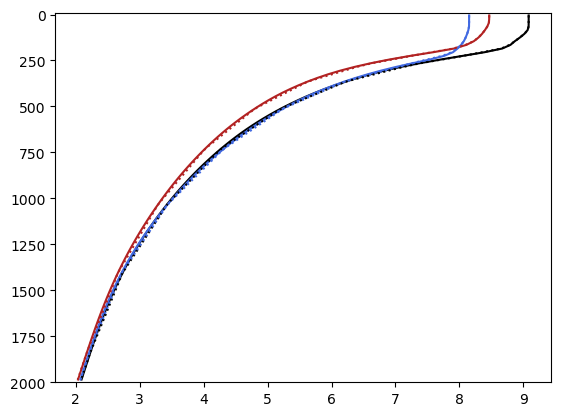

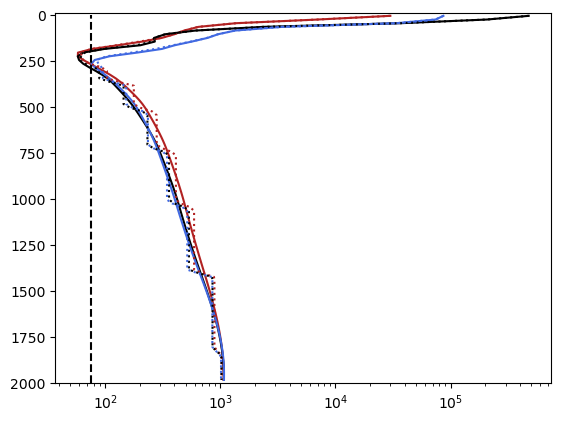

In [11]:
xx = 60; yy = 35
print(tempSEp_cub.coords['lon'].isel(x=xx,y=yy).values, tempSEp_cub.coords['lat'].isel(x=xx,y=yy).values)

plt.figure()
plt.plot(tempSEp_cub.isel(month=7,x=xx,y=yy), tempSEp_cub.coords['depth'], color='firebrick')
plt.plot(tempP_cub.isel(month=7,x=xx,y=yy), tempP_cub.coords['depth'], color='k')
plt.plot(tempSWp_cub.isel(month=7,x=xx,y=yy), tempSWp_cub.coords['depth'], color='royalblue')
plt.plot(tempSEp_lin.isel(month=7,x=xx,y=yy), tempSEp_lin.coords['depth'], color='firebrick', linestyle=':')
plt.plot(tempP_lin.isel(month=7,x=xx,y=yy), tempP_lin.coords['depth'], color='k', linestyle=':')
plt.plot(tempSWp_lin.isel(month=7,x=xx,y=yy), tempSWp_lin.coords['depth'], color='royalblue', linestyle=':')
plt.ylim(2000,-10)

plt.figure()
plt.plot(np.abs(dzdtSEp_cub.isel(month=7,x=xx,y=yy)), dtdzSEp_cub.coords['depth'], color='firebrick')
plt.plot(np.abs(dzdtP_cub.isel(month=7,x=xx,y=yy)), dtdzP_cub.coords['depth'], color='k')
plt.plot(np.abs(dzdtSWp_cub.isel(month=7,x=xx,y=yy)), dtdzSWp_cub.coords['depth'], color='royalblue')
plt.plot(np.abs(dzdtSEp_lin.isel(month=7,x=xx,y=yy)), dtdzSEp_lin.coords['depth'], color='firebrick', linestyle=":")
plt.plot(np.abs(dzdtP_lin.isel(month=7,x=xx,y=yy)), dtdzP_lin.coords['depth'], color='k', linestyle=":")
plt.plot(np.abs(dzdtSWp_lin.isel(month=7,x=xx,y=yy)), dtdzSWp_lin.coords['depth'], color='royalblue', linestyle=":")
plt.ylim(2000,-10)
plt.plot((75,75), (2000,0), 'k--')
plt.xscale('log')


## get the isopycnal bounds and select grid cells belonging to SAMW

In [12]:
### set bounds for SAMW
samw_rho0_bnds = np.array([26.5, 27.1])
samw_lati_bnds = np.array([-90., -20.])
samw_dzdt_bnds = np.array([75.0])
### set bounds for AAIW
aaiw_lati_bnds = np.array([-90., -20.])
aaiw_rho0_bnds = np.array([27.1, 27.5])



In [13]:
%%time

samw_lin = rho0_lin*0 + 1.0
samw_lin = samw_lin.where(rho0_lin > samw_rho0_bnds[0], other=0.0).where(rho0_lin < samw_rho0_bnds[1], other=0.0)
samw_lin = samw_lin.where(samw_lin.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samw_lin.coords['lat'] < samw_lati_bnds[1], other=0.0)
samw_lin = samw_lin.where(dzdt_lin > samw_dzdt_bnds[0], other=0.0)
samw_lin_volume = (samw_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

samw_cub = rho0_cub*0 + 1.0
samw_cub = samw_cub.where(rho0_cub > samw_rho0_bnds[0], other=0.0).where(rho0_cub < samw_rho0_bnds[1], other=0.0)
samw_cub = samw_cub.where(samw_cub.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samw_cub.coords['lat'] < samw_lati_bnds[1], other=0.0)
samw_cub = samw_cub.where(dzdt_cub > samw_dzdt_bnds[0], other=0.0)
samw_cub_volume = (samw_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiw_lin = rho0_lin*0 + 1.0
aaiw_lin = aaiw_lin.where(rho0_lin > aaiw_rho0_bnds[0], other=0.0).where(rho0_lin < aaiw_rho0_bnds[1], other=0.0)
aaiw_lin = aaiw_lin.where(aaiw_lin.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiw_lin.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiw_lin_volume = (aaiw_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiw_cub = rho0_cub*0 + 1.0
aaiw_cub = aaiw_cub.where(rho0_cub > aaiw_rho0_bnds[0], other=0.0).where(rho0_cub < aaiw_rho0_bnds[1], other=0.0)
aaiw_cub = aaiw_cub.where(aaiw_cub.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiw_cub.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiw_cub_volume = (aaiw_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3


CPU times: user 141 ms, sys: 895 μs, total: 142 ms
Wall time: 142 ms


In [14]:
%%time

samwP_lin = rho0P_lin*0 + 1.0
samwP_lin = samwP_lin.where(rho0P_lin > samw_rho0_bnds[0], other=0.0).where(rho0P_lin < samw_rho0_bnds[1], other=0.0)
samwP_lin = samwP_lin.where(samwP_lin.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samwP_lin.coords['lat'] < samw_lati_bnds[1], other=0.0)
samwP_lin = samwP_lin.where(dzdtP_lin > samw_dzdt_bnds[0], other=0.0)
samwP_lin_volume = (samwP_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

samwP_cub = rho0P_cub*0 + 1.0
samwP_cub = samwP_cub.where(rho0P_cub > samw_rho0_bnds[0], other=0.0).where(rho0P_cub < samw_rho0_bnds[1], other=0.0)
samwP_cub = samwP_cub.where(samwP_cub.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samwP_cub.coords['lat'] < samw_lati_bnds[1], other=0.0)
samwP_cub = samwP_cub.where(dzdtP_cub > samw_dzdt_bnds[0], other=0.0)
samwP_cub_volume = (samwP_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiwP_lin = rho0P_lin*0 + 1.0
aaiwP_lin = aaiwP_lin.where(rho0P_lin > aaiw_rho0_bnds[0], other=0.0).where(rho0P_lin < aaiw_rho0_bnds[1], other=0.0)
aaiwP_lin = aaiwP_lin.where(aaiwP_lin.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiwP_lin.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiwP_lin_volume = (aaiwP_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiwP_cub = rho0P_cub*0 + 1.0
aaiwP_cub = aaiwP_cub.where(rho0P_cub > aaiw_rho0_bnds[0], other=0.0).where(rho0P_cub < aaiw_rho0_bnds[1], other=0.0)
aaiwP_cub = aaiwP_cub.where(aaiwP_cub.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiwP_cub.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiwP_cub_volume = (aaiwP_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3


CPU times: user 137 ms, sys: 105 μs, total: 137 ms
Wall time: 137 ms


In [23]:
%%time

samwI_lin = rho0I_lin*0 + 1.0
samwI_lin = samwI_lin.where(rho0I_lin > samw_rho0_bnds[0], other=0.0).where(rho0I_lin < samw_rho0_bnds[1], other=0.0)
samwI_lin = samwI_lin.where(samwI_lin.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samwI_lin.coords['lat'] < samw_lati_bnds[1], other=0.0)
samwI_lin = samwI_lin.where(dzdtI_lin > samw_dzdt_bnds[0], other=0.0)
samwI_lin_volume = (samwI_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

samwI_cub = rho0I_cub*0 + 1.0
samwI_cub = samwI_cub.where(rho0I_cub > samw_rho0_bnds[0], other=0.0).where(rho0I_cub < samw_rho0_bnds[1], other=0.0)
samwI_cub = samwI_cub.where(samwI_cub.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samwI_cub.coords['lat'] < samw_lati_bnds[1], other=0.0)
samwI_cub = samwI_cub.where(dzdtI_cub > samw_dzdt_bnds[0], other=0.0)
samwI_cub_volume = (samwI_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiwI_lin = rho0I_lin*0 + 1.0
aaiwI_lin = aaiwI_lin.where(rho0I_lin > aaiw_rho0_bnds[0], other=0.0).where(rho0I_lin < aaiw_rho0_bnds[1], other=0.0)
aaiwI_lin = aaiwI_lin.where(aaiwI_lin.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiwI_lin.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiwI_lin_volume = (aaiwI_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiwI_cub = rho0I_cub*0 + 1.0
aaiwI_cub = aaiwI_cub.where(rho0I_cub > aaiw_rho0_bnds[0], other=0.0).where(rho0I_cub < aaiw_rho0_bnds[1], other=0.0)
aaiwI_cub = aaiwI_cub.where(aaiwI_cub.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiwI_cub.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiwI_cub_volume = (aaiwI_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3


CPU times: user 137 ms, sys: 6.34 ms, total: 144 ms
Wall time: 144 ms


In [25]:
%%time


samwSEp_lin = rho0SEp_lin*0 + 1.0
samwSEp_lin = samwSEp_lin.where(rho0SEp_lin > samw_rho0_bnds[0], other=0.0).where(rho0SEp_lin < samw_rho0_bnds[1], other=0.0)
samwSEp_lin = samwSEp_lin.where(samwSEp_lin.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samwSEp_lin.coords['lat'] < samw_lati_bnds[1], other=0.0)
samwSEp_lin = samwSEp_lin.where(dzdtSEp_lin > samw_dzdt_bnds[0], other=0.0)
samwSEp_lin_volume = (samwSEp_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

samwSEp_cub = rho0SEp_cub*0 + 1.0
samwSEp_cub = samwSEp_cub.where(rho0SEp_cub > samw_rho0_bnds[0], other=0.0).where(rho0SEp_cub < samw_rho0_bnds[1], other=0.0)
samwSEp_cub = samwSEp_cub.where(samwSEp_cub.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samwSEp_cub.coords['lat'] < samw_lati_bnds[1], other=0.0)
samwSEp_cub = samwSEp_cub.where(dzdtSEp_cub > samw_dzdt_bnds[0], other=0.0)
samwSEp_cub_volume = (samwSEp_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiwSEp_lin = rho0SEp_lin*0 + 1.0
aaiwSEp_lin = aaiwSEp_lin.where(rho0SEp_lin > aaiw_rho0_bnds[0], other=0.0).where(rho0SEp_lin < aaiw_rho0_bnds[1], other=0.0)
aaiwSEp_lin = aaiwSEp_lin.where(aaiwSEp_lin.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiwSEp_lin.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiwSEp_lin_volume = (aaiwSEp_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiwSEp_cub = rho0SEp_cub*0 + 1.0
aaiwSEp_cub = aaiwSEp_cub.where(rho0SEp_cub > aaiw_rho0_bnds[0], other=0.0).where(rho0SEp_cub < aaiw_rho0_bnds[1], other=0.0)
aaiwSEp_cub = aaiwSEp_cub.where(aaiwSEp_cub.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiwSEp_cub.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiwSEp_cub_volume = (aaiwSEp_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

samwSWp_lin = rho0SWp_lin*0 + 1.0
samwSWp_lin = samwSWp_lin.where(rho0SWp_lin > samw_rho0_bnds[0], other=0.0).where(rho0SWp_lin < samw_rho0_bnds[1], other=0.0)
samwSWp_lin = samwSWp_lin.where(samwSWp_lin.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samwSWp_lin.coords['lat'] < samw_lati_bnds[1], other=0.0)
samwSWp_lin = samwSWp_lin.where(dzdtSWp_lin > samw_dzdt_bnds[0], other=0.0)
samwSWp_lin_volume = (samwSWp_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

samwSWp_cub = rho0SWp_cub*0 + 1.0
samwSWp_cub = samwSWp_cub.where(rho0SWp_cub > samw_rho0_bnds[0], other=0.0).where(rho0SWp_cub < samw_rho0_bnds[1], other=0.0)
samwSWp_cub = samwSWp_cub.where(samwSWp_cub.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samwSWp_cub.coords['lat'] < samw_lati_bnds[1], other=0.0)
samwSWp_cub = samwSWp_cub.where(dzdtSWp_cub > samw_dzdt_bnds[0], other=0.0)
samwSWp_cub_volume = (samwSWp_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiwSWp_lin = rho0SWp_lin*0 + 1.0
aaiwSWp_lin = aaiwSWp_lin.where(rho0SWp_lin > aaiw_rho0_bnds[0], other=0.0).where(rho0SWp_lin < aaiw_rho0_bnds[1], other=0.0)
aaiwSWp_lin = aaiwSWp_lin.where(aaiwSWp_lin.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiwSWp_lin.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiwSWp_lin_volume = (aaiwSWp_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiwSWp_cub = rho0SWp_cub*0 + 1.0
aaiwSWp_cub = aaiwSWp_cub.where(rho0SWp_cub > aaiw_rho0_bnds[0], other=0.0).where(rho0SWp_cub < aaiw_rho0_bnds[1], other=0.0)
aaiwSWp_cub = aaiwSWp_cub.where(aaiwSWp_cub.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiwSWp_cub.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiwSWp_cub_volume = (aaiwSWp_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3



CPU times: user 276 ms, sys: 1.44 ms, total: 277 ms
Wall time: 278 ms


In [26]:
%%time 


samwSEi_lin = rho0SEi_lin*0 + 1.0
samwSEi_lin = samwSEi_lin.where(rho0SEi_lin > samw_rho0_bnds[0], other=0.0).where(rho0SEi_lin < samw_rho0_bnds[1], other=0.0)
samwSEi_lin = samwSEi_lin.where(samwSEi_lin.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samwSEi_lin.coords['lat'] < samw_lati_bnds[1], other=0.0)
samwSEi_lin = samwSEi_lin.where(dzdtSEi_lin > samw_dzdt_bnds[0], other=0.0)
samwSEi_lin_volume = (samwSEi_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiwSEi_lin = rho0SEi_lin*0 + 1.0
aaiwSEi_lin = aaiwSEi_lin.where(rho0SEi_lin > aaiw_rho0_bnds[0], other=0.0).where(rho0SEi_lin < aaiw_rho0_bnds[1], other=0.0)
aaiwSEi_lin = aaiwSEi_lin.where(aaiwSEi_lin.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiwSEi_lin.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiwSEi_lin_volume = (aaiwSEi_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

samwSWi_lin = rho0SWi_lin*0 + 1.0
samwSWi_lin = samwSWi_lin.where(rho0SWi_lin > samw_rho0_bnds[0], other=0.0).where(rho0SWi_lin < samw_rho0_bnds[1], other=0.0)
samwSWi_lin = samwSWi_lin.where(samwSWi_lin.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samwSWi_lin.coords['lat'] < samw_lati_bnds[1], other=0.0)
samwSWi_lin = samwSWi_lin.where(dzdtSWi_lin > samw_dzdt_bnds[0], other=0.0)
samwSWi_lin_volume = (samwSWi_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiwSWi_lin = rho0SWi_lin*0 + 1.0
aaiwSWi_lin = aaiwSWi_lin.where(rho0SWi_lin > aaiw_rho0_bnds[0], other=0.0).where(rho0SWi_lin < aaiw_rho0_bnds[1], other=0.0)
aaiwSWi_lin = aaiwSWi_lin.where(aaiwSWi_lin.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiwSWi_lin.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiwSWi_lin_volume = (aaiwSWi_lin * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

samwSEi_cub = rho0SEi_cub*0 + 1.0
samwSEi_cub = samwSEi_cub.where(rho0SEi_cub > samw_rho0_bnds[0], other=0.0).where(rho0SEi_cub < samw_rho0_bnds[1], other=0.0)
samwSEi_cub = samwSEi_cub.where(samwSEi_cub.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samwSEi_cub.coords['lat'] < samw_lati_bnds[1], other=0.0)
samwSEi_cub = samwSEi_cub.where(dzdtSEi_cub > samw_dzdt_bnds[0], other=0.0)
samwSEi_cub_volume = (samwSEi_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiwSEi_cub = rho0SEi_cub*0 + 1.0
aaiwSEi_cub = aaiwSEi_cub.where(rho0SEi_cub > aaiw_rho0_bnds[0], other=0.0).where(rho0SEi_cub < aaiw_rho0_bnds[1], other=0.0)
aaiwSEi_cub = aaiwSEi_cub.where(aaiwSEi_cub.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiwSEi_cub.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiwSEi_cub_volume = (aaiwSEi_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

samwSWi_cub = rho0SWi_cub*0 + 1.0
samwSWi_cub = samwSWi_cub.where(rho0SWi_cub > samw_rho0_bnds[0], other=0.0).where(rho0SWi_cub < samw_rho0_bnds[1], other=0.0)
samwSWi_cub = samwSWi_cub.where(samwSWi_cub.coords['lat'] > samw_lati_bnds[0], other=0.0).where(samwSWi_cub.coords['lat'] < samw_lati_bnds[1], other=0.0)
samwSWi_cub = samwSWi_cub.where(dzdtSWi_cub > samw_dzdt_bnds[0], other=0.0)
samwSWi_cub_volume = (samwSWi_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3

aaiwSWi_cub = rho0SWi_cub*0 + 1.0
aaiwSWi_cub = aaiwSWi_cub.where(rho0SWi_cub > aaiw_rho0_bnds[0], other=0.0).where(rho0SWi_cub < aaiw_rho0_bnds[1], other=0.0)
aaiwSWi_cub = aaiwSWi_cub.where(aaiwSWi_cub.coords['lat'] > aaiw_lati_bnds[0], other=0.0).where(aaiwSWi_cub.coords['lat'] < aaiw_lati_bnds[1], other=0.0)
aaiwSWi_cub_volume = (aaiwSWi_cub * vol).drop_vars(['nav_lon', 'nav_lat', 'time_centered'])    # m3


CPU times: user 273 ms, sys: 2.67 ms, total: 276 ms
Wall time: 276 ms


## Save these arrays to disk

In [18]:
samw_lin

<xarray.DataArray 'so' (year: 65, month: 12, depth: 100, y: 149, x: 182)> Size: 17GB
dask.array<where, shape=(65, 12, 100, 149, 182), dtype=float64, chunksize=(1, 1, 100, 149, 182), chunktype=numpy.ndarray>
Coordinates:
    lat      (y, x) float32 108kB -78.19 -78.19 -78.19 -78.19 ... -1.0 -1.0 -1.0
    lon      (y, x) float32 108kB 78.0 80.0 82.0 84.0 ... -1.0 -1.0 -1.0 -1.0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * year     (year) float64 520B 1.958e+03 1.96e+03 ... 2.022e+03 2.022e+03
  * depth    (depth) int64 800B 5 25 45 65 85 105 ... 1905 1925 1945 1965 1985
Dimensions without coordinates: y, x

In [21]:
%%time

os.getcwd()

#samw_lin.to_netcdf("JRA55_pic_1m_SAMW_linear_1958-2022.nc", mode="w")
samw_cub.to_netcdf("JRA55_pic_1m_SAMW_cubic_1958-2022.nc", mode="w")
#aaiw_lin.to_netcdf("JRA55_pic_1m_AAIW_linear_1958-2022.nc", mode="w")
aaiw_cub.to_netcdf("JRA55_pic_1m_AAIW_cubic_1958-2022.nc", mode="w")



[########################################] | 100% Completed | 22m 3ss
[########################################] | 100% Completed | 21m 14s
CPU times: user 42min 19s, sys: 26min 40s, total: 1h 8min 59s
Wall time: 43min 21s


In [29]:
%%time

temp_cub.to_netcdf("JRA55_pic_1m_temp_cubic_1958-2022.nc", mode="w")
temp_lin.to_netcdf("JRA55_pic_1m_temp_linear_1958-2022.nc", mode="w")

salt_cub.to_netcdf("JRA55_pic_1m_salt_cubic_1958-2022.nc", mode="w")
salt_lin.to_netcdf("JRA55_pic_1m_salt_linear_1958-2022.nc", mode="w")

rho0_cub.to_netcdf("JRA55_pic_1m_rho0_cubic_1958-2022.nc", mode="w")
rho0_lin.to_netcdf("JRA55_pic_1m_rho0_linear_1958-2022.nc", mode="w")



[########################################] | 100% Completed | 20m 38s
[########################################] | 100% Completed | 12.74 s
[########################################] | 100% Completed | 10m 22s
[########################################] | 100% Completed | 12.80 s
[########################################] | 100% Completed | 20m 37s
[########################################] | 100% Completed | 26.88 s
CPU times: user 51min 37s, sys: 32min 9s, total: 1h 23min 46s
Wall time: 52min 35s


In [ ]:
%%time

samwP_lin.to_netcdf("JRA55_pic_1m_SAMW_Pac_linear_2022.nc", mode="w")
samwI_lin.to_netcdf("JRA55_pic_1m_SAMW_Ind_linear_2022.nc", mode="w")
aaiwP_lin.to_netcdf("JRA55_pic_1m_AAIW_Pac_linear_2022.nc", mode="w")
aaiwI_lin.to_netcdf("JRA55_pic_1m_AAIW_Ind_linear_2022.nc", mode="w")

samwSEp_lin.to_netcdf("JRA55_pic_1m_SAMW_SEp_linear_2022.nc", mode="w")
samwSWp_lin.to_netcdf("JRA55_pic_1m_SAMW_SWp_linear_2022.nc", mode="w")
samwSEi_lin.to_netcdf("JRA55_pic_1m_SAMW_SEi_linear_2022.nc", mode="w")
samwSWi_lin.to_netcdf("JRA55_pic_1m_SAMW_SWi_linear_2022.nc", mode="w")

aaiwSEp_lin.to_netcdf("JRA55_pic_1m_AAIW_SEp_linear_2022.nc", mode="w")
aaiwSWp_lin.to_netcdf("JRA55_pic_1m_AAIW_SWp_linear_2022.nc", mode="w")
aaiwSEi_lin.to_netcdf("JRA55_pic_1m_AAIW_SEi_linear_2022.nc", mode="w")
aaiwSWi_lin.to_netcdf("JRA55_pic_1m_AAIW_SWi_linear_2022.nc", mode="w")


In [28]:
%%time

samwP_cub.to_netcdf("JRA55_pic_1m_SAMW_Pac_cubic_2022.nc", mode="w")
samwI_cub.to_netcdf("JRA55_pic_1m_SAMW_Ind_cubic_2022.nc", mode="w")
aaiwP_cub.to_netcdf("JRA55_pic_1m_AAIW_Pac_cubic_2022.nc", mode="w")
aaiwI_cub.to_netcdf("JRA55_pic_1m_AAIW_Ind_cubic_2022.nc", mode="w")

samwSEp_cub.to_netcdf("JRA55_pic_1m_SAMW_SEp_cubic_2022.nc", mode="w")
samwSWp_cub.to_netcdf("JRA55_pic_1m_SAMW_SWp_cubic_2022.nc", mode="w")
samwSEi_cub.to_netcdf("JRA55_pic_1m_SAMW_SEi_cubic_2022.nc", mode="w")
samwSWi_cub.to_netcdf("JRA55_pic_1m_SAMW_SWi_cubic_2022.nc", mode="w")

aaiwSEp_cub.to_netcdf("JRA55_pic_1m_AAIW_SEp_cubic_2022.nc", mode="w")
aaiwSWp_cub.to_netcdf("JRA55_pic_1m_AAIW_SWp_cubic_2022.nc", mode="w")
aaiwSEi_cub.to_netcdf("JRA55_pic_1m_AAIW_SEi_cubic_2022.nc", mode="w")
aaiwSWi_cub.to_netcdf("JRA55_pic_1m_AAIW_SWi_cubic_2022.nc", mode="w")


[########################################] | 100% Completed | 19.07 ss
[########################################] | 100% Completed | 18.94 ss
[########################################] | 100% Completed | 18.86 ss
[########################################] | 100% Completed | 19.05 ss
[########################################] | 100% Completed | 20.50 s
[########################################] | 100% Completed | 19.16 ss
[########################################] | 100% Completed | 19.41 ss
[########################################] | 100% Completed | 19.17 ss
[########################################] | 100% Completed | 18.88 ss
[########################################] | 100% Completed | 19.29 ss
[########################################] | 100% Completed | 19.11 ss
[########################################] | 100% Completed | 18.86 ss
CPU times: user 3min 43s, sys: 2min 19s, total: 6min 2s
Wall time: 3min 54s


In [30]:
%%time

tempP_lin.to_netcdf("JRA55_pic_1m_temp_Pac_linear_2022.nc", mode="w")
tempI_lin.to_netcdf("JRA55_pic_1m_temp_Ind_linear_2022.nc", mode="w")
saltP_lin.to_netcdf("JRA55_pic_1m_salt_Pac_linear_2022.nc", mode="w")
saltI_lin.to_netcdf("JRA55_pic_1m_salt_Ind_linear_2022.nc", mode="w")
rho0P_lin.to_netcdf("JRA55_pic_1m_rho0_Pac_linear_2022.nc", mode="w")
rho0I_lin.to_netcdf("JRA55_pic_1m_rho0_Ind_linear_2022.nc", mode="w")

tempSEp_lin.to_netcdf("JRA55_pic_1m_temp_SEp_linear_2022.nc", mode="w")
tempSWp_lin.to_netcdf("JRA55_pic_1m_temp_SWp_linear_2022.nc", mode="w")
tempSEi_lin.to_netcdf("JRA55_pic_1m_temp_SEi_linear_2022.nc", mode="w")
tempSWi_lin.to_netcdf("JRA55_pic_1m_temp_SWi_linear_2022.nc", mode="w")

saltSEp_lin.to_netcdf("JRA55_pic_1m_salt_SEp_linear_2022.nc", mode="w")
saltSWp_lin.to_netcdf("JRA55_pic_1m_salt_SWp_linear_2022.nc", mode="w")
saltSEi_lin.to_netcdf("JRA55_pic_1m_salt_SEi_linear_2022.nc", mode="w")
saltSWi_lin.to_netcdf("JRA55_pic_1m_salt_SWi_linear_2022.nc", mode="w")

rho0SEp_lin.to_netcdf("JRA55_pic_1m_rho0_SEp_linear_2022.nc", mode="w")
rho0SWp_lin.to_netcdf("JRA55_pic_1m_rho0_SWp_linear_2022.nc", mode="w")
rho0SEi_lin.to_netcdf("JRA55_pic_1m_rho0_SEi_linear_2022.nc", mode="w")
rho0SWi_lin.to_netcdf("JRA55_pic_1m_rho0_SWi_linear_2022.nc", mode="w")

tempP_cub.to_netcdf("JRA55_pic_1m_temp_Pac_cubic_2022.nc", mode="w")
tempI_cub.to_netcdf("JRA55_pic_1m_temp_Ind_cubic_2022.nc", mode="w")
saltP_cub.to_netcdf("JRA55_pic_1m_salt_Pac_cubic_2022.nc", mode="w")
saltI_cub.to_netcdf("JRA55_pic_1m_salt_Ind_cubic_2022.nc", mode="w")
rho0P_cub.to_netcdf("JRA55_pic_1m_rho0_Pac_cubic_2022.nc", mode="w")
rho0I_cub.to_netcdf("JRA55_pic_1m_rho0_Ind_cubic_2022.nc", mode="w")

tempSEp_cub.to_netcdf("JRA55_pic_1m_temp_SEp_cubic_2022.nc", mode="w")
tempSWp_cub.to_netcdf("JRA55_pic_1m_temp_SWp_cubic_2022.nc", mode="w")
tempSEi_cub.to_netcdf("JRA55_pic_1m_temp_SEi_cubic_2022.nc", mode="w")
tempSWi_cub.to_netcdf("JRA55_pic_1m_temp_SWi_cubic_2022.nc", mode="w")

saltSEp_cub.to_netcdf("JRA55_pic_1m_salt_SEp_cubic_2022.nc", mode="w")
saltSWp_cub.to_netcdf("JRA55_pic_1m_salt_SWp_cubic_2022.nc", mode="w")
saltSEi_cub.to_netcdf("JRA55_pic_1m_salt_SEi_cubic_2022.nc", mode="w")
saltSWi_cub.to_netcdf("JRA55_pic_1m_salt_SWi_cubic_2022.nc", mode="w")

rho0SEp_cub.to_netcdf("JRA55_pic_1m_rho0_SEp_cubic_2022.nc", mode="w")
rho0SWp_cub.to_netcdf("JRA55_pic_1m_rho0_SWp_cubic_2022.nc", mode="w")
rho0SEi_cub.to_netcdf("JRA55_pic_1m_rho0_SEi_cubic_2022.nc", mode="w")
rho0SWi_cub.to_netcdf("JRA55_pic_1m_rho0_SWi_cubic_2022.nc", mode="w")


[########################################] | 100% Completed | 5.23 sms
[########################################] | 100% Completed | 504.64 ms
[########################################] | 100% Completed | 304.73 ms
[########################################] | 100% Completed | 303.57 ms
[########################################] | 100% Completed | 405.53 ms
[########################################] | 100% Completed | 507.78 ms
[########################################] | 100% Completed | 1.01 sms
[########################################] | 100% Completed | 604.95 ms
[########################################] | 100% Completed | 806.34 ms
[########################################] | 100% Completed | 1.11 sms
[########################################] | 100% Completed | 2.41 sms
[########################################] | 100% Completed | 302.75 ms
[########################################] | 100% Completed | 303.01 ms
[########################################] | 100% Completed | 303.10

In [28]:
samwSEp_lin

<xarray.DataArray 'so' (month: 12, depth: 100, y: 149, x: 182)> Size: 260MB
dask.array<where, shape=(12, 100, 149, 182), dtype=float64, chunksize=(1, 100, 149, 182), chunktype=numpy.ndarray>
Coordinates:
    lat      (y, x) float32 108kB -78.19 -78.19 -78.19 -78.19 ... -1.0 -1.0 -1.0
    lon      (y, x) float32 108kB 78.0 80.0 82.0 84.0 ... -1.0 -1.0 -1.0 -1.0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * depth    (depth) int64 800B 5 25 45 65 85 105 ... 1905 1925 1945 1965 1985
Dimensions without coordinates: y, x

[########################################] | 100% Completed | 19.94 ss
[########################################] | 100% Completed | 19.97 s


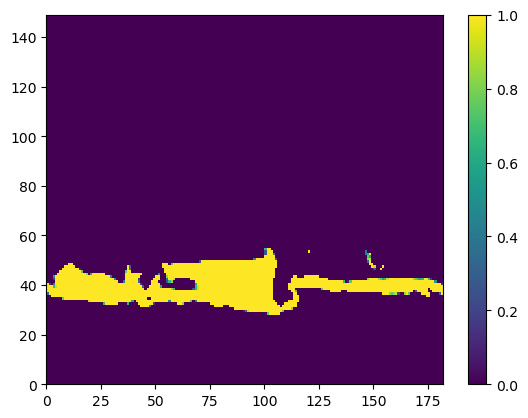

In [29]:
plt.figure()
plt.pcolormesh(samwSEp_lin.mean(dim='month').isel(depth=20))
plt.colorbar()